In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [242]:
df = pd.read_csv('Companies_dataset.csv')


In [243]:
df.describe()

,Unnamed: 0,ratings
count,30.000000,30.000000
mean,4407.533333,3.946667
std,2810.407514,0.311540
min,268.000000,3.300000
25%,1863.750000,3.800000
50%,4270.000000,4.000000
75%,7021.000000,4.175000
max,8767.000000,4.600000


In [244]:
df.head()

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,7958,Farmson Pharmace...,3.4,(76 Reviews),Vadodara + 5 more,501-1k Employees (India),53 years old,NaN
1,5118,SEForge,3.6,(121 Reviews),Private,17 years old,Coimbatore + 4 more,201-500 Employees (India)
2,8613,Kalinga Universi...,3.4,(70 Reviews),Raipur + 7 more,201-500 Employees (India),10 years old,NaN
3,764,Tenneco,3.8,(754 Reviews),Private,83 years old,"Lake Forest,Illinois + 28 more",1k-5k Employees (India)
4,5265,Toyo INK,4.2,(117 Reviews),Private,17 years old,Tokyo + 9 more,11-50 Employees (India)


In [245]:
print(df.shape)
print(df.columns)
print(df.info())

(30, 8)
Index(['Unnamed: 0', 'name', 'ratings', 'review_count', 'ctype', 'years', 'hq',
       'employees'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    30 non-null     int64  
 1   name          30 non-null     object 
 2   ratings       30 non-null     float64
 3   review_count  30 non-null     object 
 4   ctype         30 non-null     object 
 5   years         27 non-null     object 
 6   hq            29 non-null     object 
 7   employees     19 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.0+ KB
None


In [246]:
import pandas as pd

# Load dataset
df = pd.read_csv('Companies_dataset.csv')

# Randomly sample 30 rows
df_sample = df.sample(n=30, random_state=42)

# Reset index (optional, cleaner output)
df_sample = df_sample.reset_index(drop=True)

# Save to new CSV
df_sample.to_csv('Companies_dataset.csv', index=False)

print("New dataset with 30 rows saved successfully!")

New dataset with 30 rows saved successfully!


In [247]:
df=pd.read_csv('Companies_dataset.csv')

In [248]:
print(df.shape)
print(df.columns)
print(df.info())

(30, 8)
Index(['Unnamed: 0', 'name', 'ratings', 'review_count', 'ctype', 'years', 'hq',
       'employees'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    30 non-null     int64  
 1   name          30 non-null     object 
 2   ratings       30 non-null     float64
 3   review_count  30 non-null     object 
 4   ctype         30 non-null     object 
 5   years         27 non-null     object 
 6   hq            29 non-null     object 
 7   employees     19 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.0+ KB
None


In [249]:
df.head()

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,268,S&P Global,4.2,(1.8k Reviews),Public,106 years old,"New York City,New York + 17 more",5k-10k Employees (India)
1,512,Mercedes-Benz Re...,4.0,(1.1k Reviews),Public,27 years old,"Bengaluru/Bangalore,Karnataka + 48 more",5k-10k Employees (India)
2,8520,Kifs Housing Fin...,3.6,(70 Reviews),Private,8 years old,Ahmedabad + 30 more,51-200 Employees (India)
3,2898,Algonomy,3.9,(212 Reviews),Private,19 years old,"Bangalore,Karnataka + 8 more",201-500 Employees (India)
4,8767,Eurofins Advinus,3.8,(68 Reviews),Bengaluru + 2 more,501-1k Employees (India),18 years old,NaN


In [250]:
df['review_count'] = df['review_count'].str.replace(r'[^0-9]', '', regex=True)
df['review_count'] = pd.to_numeric(df['review_count'], errors='coerce')

In [251]:
df['years'] = df['years'].str.extract(r'(\d+)')
df['years'] = pd.to_numeric(df['years'], errors='coerce')

In [252]:
print(df)

    Unnamed: 0                 name  ratings  review_count  \
0          268           S&P Global      4.2            18   
1          512  Mercedes-Benz Re...      4.0            11   
2         8520  Kifs Housing Fin...      3.6            70   
3         2898             Algonomy      3.9           212   
4         8767     Eurofins Advinus      3.8            68   
5         3018     Religare Finvest      4.6           204   
6         3033  Titan Laboratori...      3.7           203   
7         4300             Ican BPO      4.5           144   
8         7268  Manav Rachna Int...      3.9            84   
9         7958  Farmson Pharmace...      3.4            76   
10        5265             Toyo INK      4.2           117   
11        2292  Applied Material...      4.1           264   
12        8494       Vtc Tradewings      4.0            71   
13        4240        Ambit Finvest      4.1           147   
14        7285       Delux Bearings      4.1            84   
15      

In [253]:
df = df.drop(index=29)

In [254]:
print(df.isnull().sum())

Unnamed: 0       0
name             0
ratings          0
review_count     0
ctype            0
years            3
hq               1
employees       10
dtype: int64


In [255]:
def fix_row(row):
    # Fix misplaced years
    if isinstance(row['hq'], str) and 'years old' in row['hq']:
        row['years'] = row['hq'].split()[0]
        row['hq'] = None

    # Fix misplaced employees
    if isinstance(row['hq'], str) and 'Employees' in row['hq']:
        row['employees'] = row['hq']
        row['hq'] = None

    return row

df = df.apply(fix_row, axis=1)

In [256]:
df['years'] = df['years'].astype(str).str.extract(r'(\d+)')
df['years'] = pd.to_numeric(df['years'], errors='coerce')

In [257]:
def clean_employees(val):
    if pd.isna(val):
        return None

    val = str(val).lower().replace(',', '').strip()

    # Handle "lakh"
    if 'lakh' in val:
        return 100000

    # Handle ranges like "1k-5k"
    if '-' in val:
        parts = val.split(' ')[0].split('-')

        def convert(x):
            if 'k' in x:
                return float(x.replace('k','')) * 1000
            else:
                return float(x)

        try:
            return (convert(parts[0]) + convert(parts[1])) / 2
        except:
            return None

    # Handle single values like "50k"
    if 'k' in val:
        try:
            return float(val.replace('k','')) * 1000
        except:
            return None

    return None

In [258]:
df['employees_clean'] = df['employees'].apply(clean_employees)

In [259]:
df

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees,employees_clean
0,268,S&P Global,4.2,18,Public,106.0,"New York City,New York + 17 more",5k-10k Employees (India),7500.0
1,512,Mercedes-Benz Re...,4.0,11,Public,27.0,"Bengaluru/Bangalore,Karnataka + 48 more",5k-10k Employees (India),7500.0
2,8520,Kifs Housing Fin...,3.6,70,Private,8.0,Ahmedabad + 30 more,51-200 Employees (India),125.5
3,2898,Algonomy,3.9,212,Private,19.0,"Bangalore,Karnataka + 8 more",201-500 Employees (India),350.5
4,8767,Eurofins Advinus,3.8,68,Bengaluru + 2 more,18.0,None,NaN,NaN
5,3018,Religare Finvest,4.6,204,Public,17.0,"Delhi/NCR,Delhi + 31 more",1k-5k Employees (India),3000.0
6,3033,Titan Laboratori...,3.7,203,Private,19.0,"Mumbai,Maharashtra + 11 more",201-500 Employees (India),350.5
7,4300,Ican BPO,4.5,144,Private,14.0,Thane + 2 more,201-500 Employees (India),350.5
8,7268,Manav Rachna Int...,3.9,84,Faridabad + 2 more,26.0,None,NaN,NaN
9,7958,Farmson Pharmace...,3.4,76,Vadodara + 5 more,53.0,None,NaN,NaN


In [260]:
df[['employees', 'employees_clean']].head(10)

,employees,employees_clean
0,5k-10k Employees (India),7500.0
1,5k-10k Employees (India),7500.0
2,51-200 Employees (India),125.5
3,201-500 Employees (India),350.5
4,NaN,NaN
5,1k-5k Employees (India),3000.0
6,201-500 Employees (India),350.5
7,201-500 Employees (India),350.5
8,NaN,NaN
9,NaN,NaN


In [261]:
df['years'].fillna(df['years'].mean(), inplace=True)
df['employees_clean'].fillna(df['employees_clean'].mean(), inplace=True)
df['ratings'].fillna(df['ratings'].mean(), inplace=True)

In [262]:
print("Average Rating:", df['ratings'].mean())
print("Total Reviews:", df['review_count'].sum())
print("Average Years:", df['years'].mean())
print("Average Employees:", df['employees_clean'].mean())

Average Rating: 3.944827586206897
Total Reviews: 6005
Average Years: 32.230769230769226
Average Employees: 1971.9761904761906


In [263]:
df['hq'].fillna('Unknown', inplace=True)

In [264]:
print(df.isnull().sum())

Unnamed: 0         0
name               0
ratings            0
review_count       0
ctype              0
years              0
hq                 0
employees          8
employees_clean    0
dtype: int64


In [265]:
df

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees,employees_clean
0,268,S&P Global,4.2,18,Public,106.000000,"New York City,New York + 17 more",5k-10k Employees (India),7500.00000
1,512,Mercedes-Benz Re...,4.0,11,Public,27.000000,"Bengaluru/Bangalore,Karnataka + 48 more",5k-10k Employees (India),7500.00000
2,8520,Kifs Housing Fin...,3.6,70,Private,8.000000,Ahmedabad + 30 more,51-200 Employees (India),125.50000
3,2898,Algonomy,3.9,212,Private,19.000000,"Bangalore,Karnataka + 8 more",201-500 Employees (India),350.50000
4,8767,Eurofins Advinus,3.8,68,Bengaluru + 2 more,18.000000,Unknown,NaN,1971.97619
5,3018,Religare Finvest,4.6,204,Public,17.000000,"Delhi/NCR,Delhi + 31 more",1k-5k Employees (India),3000.00000
6,3033,Titan Laboratori...,3.7,203,Private,19.000000,"Mumbai,Maharashtra + 11 more",201-500 Employees (India),350.50000
7,4300,Ican BPO,4.5,144,Private,14.000000,Thane + 2 more,201-500 Employees (India),350.50000
8,7268,Manav Rachna Int...,3.9,84,Faridabad + 2 more,26.000000,Unknown,NaN,1971.97619
9,7958,Farmson Pharmace...,3.4,76,Vadodara + 5 more,53.000000,Unknown,NaN,1971.97619


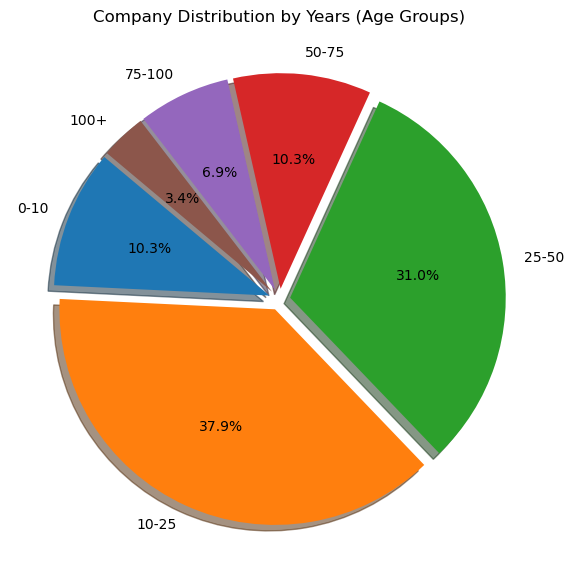

In [266]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (if not already loaded)
# df = pd.read_csv('/content/cleaned_company_dataset.csv')

# Step 1: Create age groups
bins = [0, 10, 25, 50, 75, 100, 200]
labels = ['0-10', '10-25', '25-50', '50-75', '75-100', '100+']

df['year_group'] = pd.cut(df['years'], bins=bins, labels=labels)

# Step 2: Count companies in each group
year_counts = df['year_group'].value_counts().sort_index()

# Step 3: Plot pie chart
plt.figure(figsize=(7,7))

plt.pie(
    year_counts,
    labels=year_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05]*len(year_counts),  # optional highlight effect
    shadow=True
)

plt.title("Company Distribution by Years (Age Groups)")
plt.show()

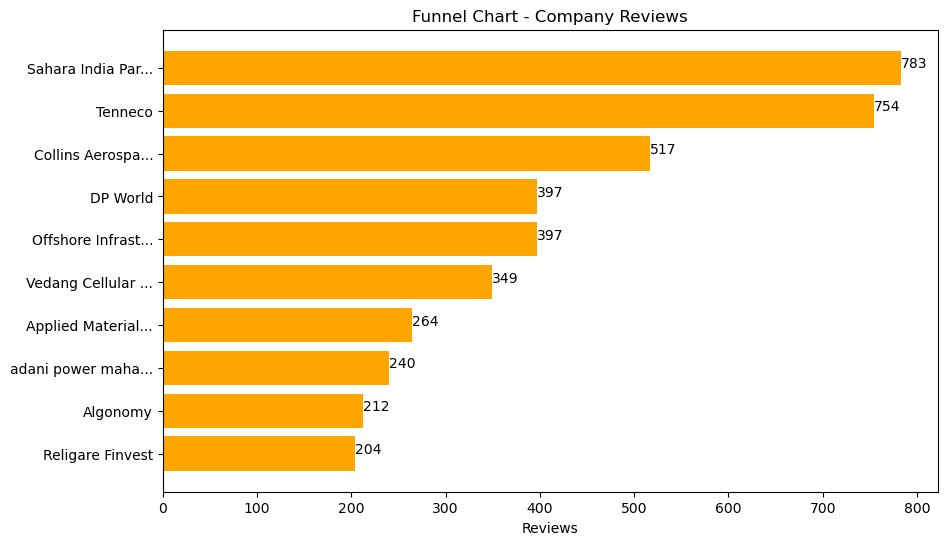

In [267]:
from sympy import to_dnf

plt.figure(figsize=(10,6))

plt.barh(
    top_df['name'],
    top_df['review_count'],
    color='orange'
)

plt.xlabel("Reviews")
plt.title("Funnel Chart - Company Reviews")

plt.gca().invert_yaxis()

# Add values on barsS
for i, v in enumerate(top_df['review_count']):
    plt.text(v, i, str(v))

plt.show()

In [268]:
h=df[['name','hq']].head(10)
display(h)

,name,hq
0,S&P Global,"New York City,New York + 17 more"
1,Mercedes-Benz Re...,"Bengaluru/Bangalore,Karnataka + 48 more"
2,Kifs Housing Fin...,Ahmedabad + 30 more
3,Algonomy,"Bangalore,Karnataka + 8 more"
4,Eurofins Advinus,Unknown
5,Religare Finvest,"Delhi/NCR,Delhi + 31 more"
6,Titan Laboratori...,"Mumbai,Maharashtra + 11 more"
7,Ican BPO,Thane + 2 more
8,Manav Rachna Int...,Unknown
9,Farmson Pharmace...,Unknown


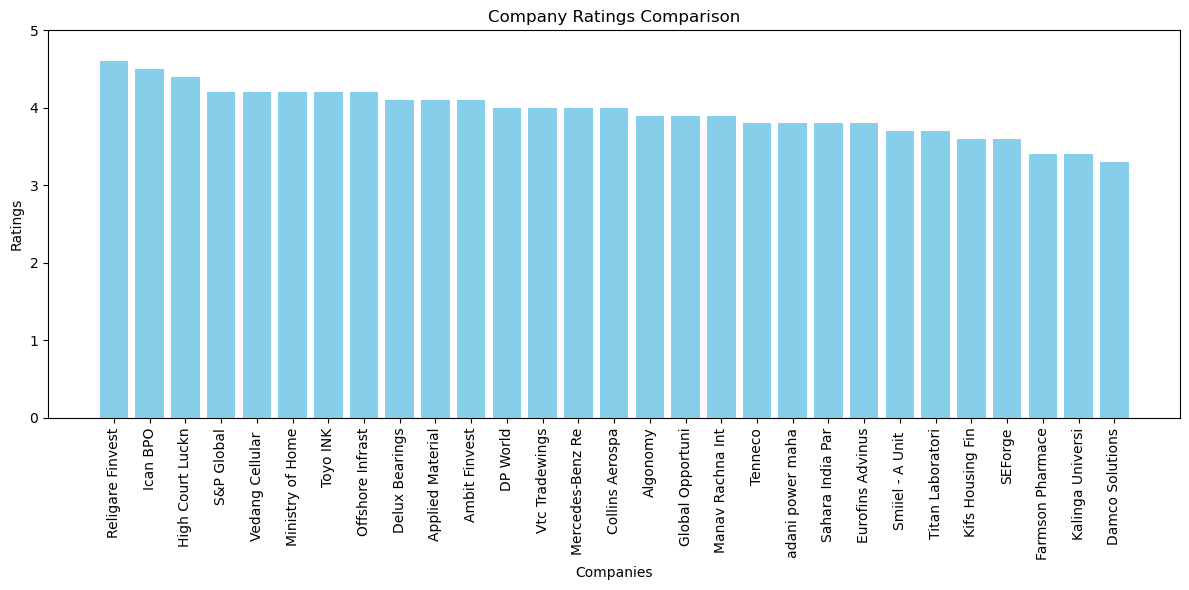

In [269]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called df
# If not, first create it:
# df = pd.read_csv("your_file.csv")

# Clean company names for better plotting (optional but recommended)
df["name_short"] = df["name"].str.replace("...", "", regex=False)

# Sort by ratings for better visualization
df_sorted = df.sort_values(by="ratings", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(df_sorted["name_short"], df_sorted["ratings"], color="skyblue")

plt.xticks(rotation=90)
plt.xlabel("Companies")
plt.ylabel("Ratings")
plt.title("Company Ratings Comparison")
plt.ylim(0, 5)  # since ratings are typically out of 5

plt.tight_layout()
plt.show()

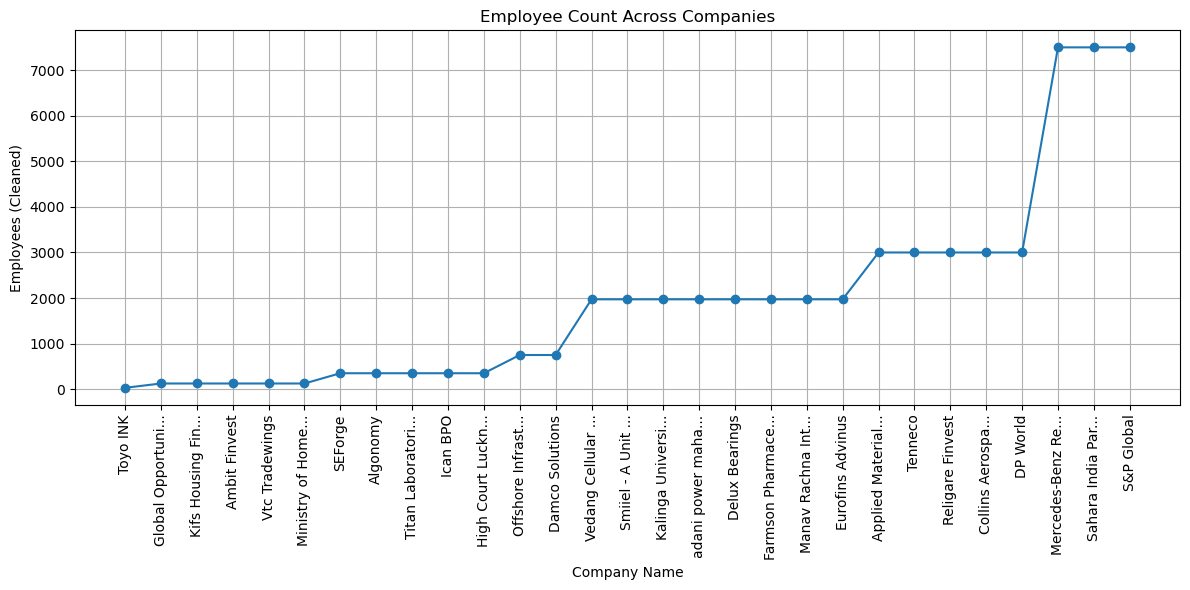

In [270]:
import matplotlib.pyplot as plt

# Sort by employee count for better visual flow
df_sorted = df.sort_values(by='employees_clean')

plt.figure(figsize=(12,6))

plt.plot(df_sorted['name'], df_sorted['employees_clean'], marker='o')

plt.xticks(rotation=90)
plt.xlabel('Company Name')
plt.ylabel('Employees (Cleaned)')
plt.title('Employee Count Across Companies')
plt.grid(True)

plt.tight_layout()
plt.show()